In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

C:\Users\hercd\AppData\Local\Temp\ipykernel_16708\2696667154.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_16708\3661565427.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_new_csv.csv", index_col= "datetime", parse_dates= True)


,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0.0,"Kozani, Greece",0.0,0.0,-12.0,40.02,0.0,0.0,0.0,23.0,3.6,292.9,1024.0,45.3,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2020-01-01 01:00:00,0.0,"Kozani, Greece",1.0,1.0,-11.0,40.33,0.0,0.0,0.0,23.4,1.8,300.4,1023.0,94.1,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 02:00:00,0.0,"Kozani, Greece",2.0,0.5,-12.0,34.62,0.0,NaN,0.0,22.2,5.4,293.6,1026.2,99.0,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 03:00:00,0.0,"Kozani, Greece",2.0,-0.8,-12.0,34.66,0.0,NaN,0.0,23.0,9.4,270.0,1023.0,98.4,NaN,0.0,0.0,0.0,Overcast,cloudy
2020-01-01 04:00:00,0.0,"Kozani, Greece",2.0,2.0,-11.0,37.54,0.0,NaN,0.0,24.8,3.6,298.2,1022.0,95.2,NaN,0.0,0.0,0.0,Overcast,cloudy


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2020-01-01 13:00:00  0.4745  Kozani, Greece   7.0        2.8  -9.0     30.99   
 2020-01-02 13:00:00  0.4737  Kozani, Greece   3.0       -2.4  -9.0     40.94   
 2020-01-03 13:00:00  0.4767  Kozani, Greece   7.0        4.2 -13.0     22.54   
 2020-01-04 13:00:00  0.4719  Kozani, Greece  11.0       11.0  -8.0     25.58   
 2020-01-05 13:00:00  0.1833  Kozani, Greece   4.0       -0.7  -2.0     64.94   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

C:\Users\hercd\AppData\Local\Temp\ipykernel_16708\1967777196.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['solarradiation'].fillna(mean_13_00, inplace=True)


In [5]:
temp = data['temp']
temp

datetime
2020-01-01 00:00:00     0.0
2020-01-01 01:00:00     1.0
2020-01-01 02:00:00     2.0
2020-01-01 03:00:00     2.0
2020-01-01 04:00:00     2.0
                       ... 
2024-07-04 19:00:00    24.0
2024-07-04 20:00:00    23.0
2024-07-04 21:00:00    21.0
2024-07-04 22:00:00    20.0
2024-07-04 23:00:00    18.0
Name: temp, Length: 39527, dtype: float64

In [6]:
def df_to_x_y(df, size = 24):
    df_as_numpy = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_numpy) - size):
        row = [[a] for a in df_as_numpy[i : i + size]]
        x.append(row)
        label = df_as_numpy[i + size]
        y.append(label)
    
    return np.array(x), np.array(y)

In [7]:
x, y = df_to_x_y(temp, size= 24)

x.shape, y.shape

((39503, 24, 1), (39503,))

In [8]:
x_train = x[: int(0.9*len(x))]
y_train = y[: int(0.9*len(y))]

x_val = x[int(0.9*len(x)): int(0.95*len(x))]
y_val = y[int(0.9*len(y)): int(0.95*len(y))]

x_test = x[int(0.95*len(x)) :]
y_test = y[int(0.95*len(y)):]

x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((35552, 24, 1), (35552,), (1975, 24, 1), (1975,), (1976, 24, 1), (1976,))

In [9]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [16]:
input_shape = (24, 1)

inputs = Input(shape=input_shape)

lstm_out = LSTM(128, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(16, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 128)   │     66,560 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 24, 128)   │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 128)   │          0 │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24, 16)    │      2,064 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 16)    │         64 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,217 (270.38 KB)

 Trainable params: 68,929 (269.25 KB)

 Non-trainable params: 288 (1.12 KB)

In [17]:
history_1 = model_1.fit(x_train, y_train, 
            validation_data = (x_val, y_val), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

Epoch 1/40
1108/1111 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 96.9664 - root_mean_squared_error: 9.6157
Epoch 1: val_loss did not improve from 2.07981
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 96.7949 - root_mean_squared_error: 9.6064 - val_loss: 21.9588 - val_root_mean_squared_error: 4.6860 - learning_rate: 0.0010
Epoch 2/40
1110/1111 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4153 - root_mean_squared_error: 2.7177
Epoch 2: val_loss did not improve from 2.07981
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 7.4132 - root_mean_squared_error: 2.7173 - val_loss: 2.8282 - val_root_mean_squared_error: 1.6817 - learning_rate: 0.0010
Epoch 3/40
1108/1111 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.8837 - root_mean_squared_error: 2.2095
Epoch 3: val_loss did not improve from 2.07981
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 4.8838 - root_mean_squared_error: 2.2095 - val_loss: 6.2531 - val_root_mean_squared_error: 2.5006 - learning_rate: 0.0010
Epoch 4/40
1110/111

In [12]:
test_predictions = model_1.predict(x_test).flatten()
test_results = pd.DataFrame({"Val Predictions" : test_predictions, "Real Data" : y_test})
test_results
test_results.index = temp.iloc[-1976:].index

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


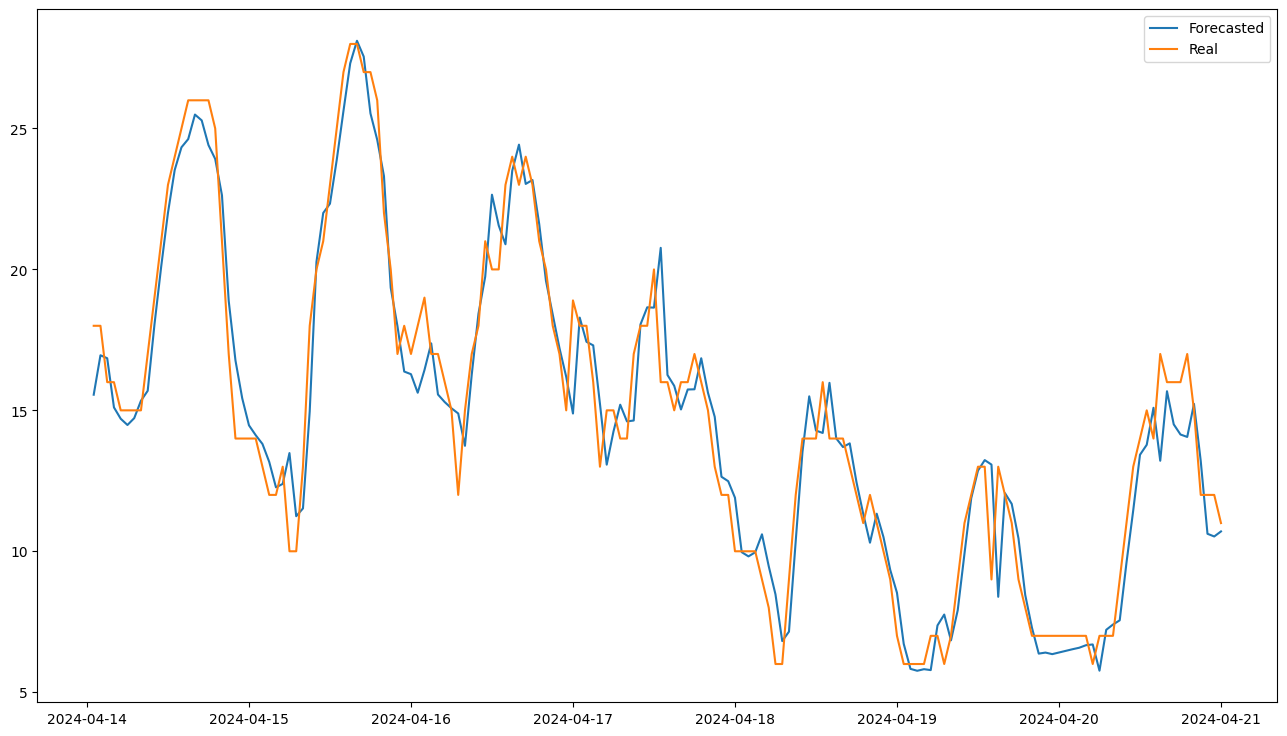

In [13]:
plt.figure(figsize= (16, 9))
plt.plot(test_results["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

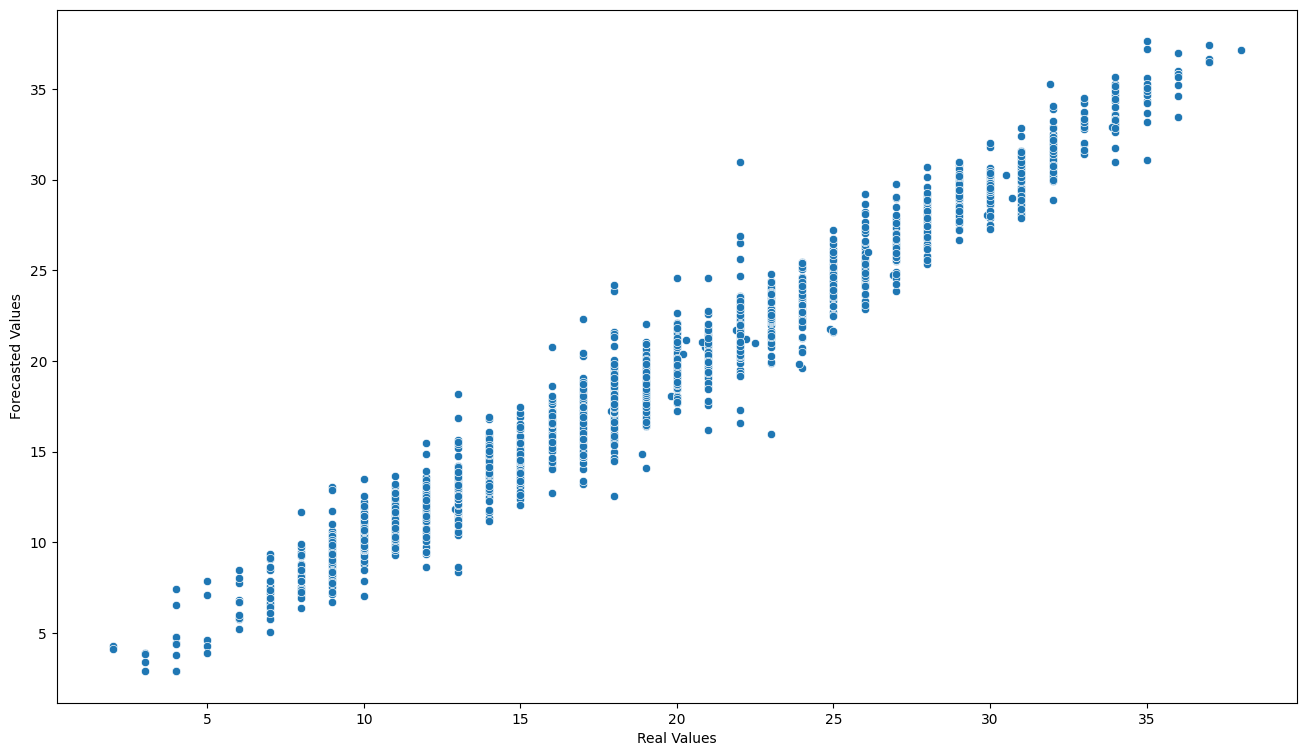

In [14]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [15]:
mse = mean_squared_error(test_results["Real Data"], test_results["Val Predictions"])
print(f" Mean Squared Error = {round(mse, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse), 5)}")

ss_total = np.sum((test_results["Real Data"] - test_results["Real Data"].mean()) ** 2)
residual = np.sum((test_results["Real Data"] - test_results["Val Predictions"]) ** 2)
r_squared = 1 - (residual / ss_total)

r_squared   #0.9677

 Mean Squared Error = 1.7304 
 Root Mean Squared Error = 1.31545


0.9666836604208114